In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

from matplotlib.lines import lineStyles

## Plotting Functions

In [16]:
def draw_line(slope, y_intercept, color='gray', linewidth=0.7, starting=0, ending=8):
    x = np.linspace(starting, ending, 1000)
    y = slope * x + y_intercept
    plt.plot(x, y, linestyle='-', color=color, linewidth=linewidth)


def plot_points(features, labels):
    x = np.array(features)
    y = np.array(labels)
    plt.scatter(x, y)
    plt.xlabel('number of rooms')
    plt.ylabel('prices')
    plt.ylim(0, 500)
    plt.show()

## Defining and plotting our dataset

In [4]:
features = np.array([1,2,3,5,6,7])
labels = np.array([155, 197, 244, 356, 407, 448])

print(features)
print(labels)

[1 2 3 5 6 7]
[155 197 244 356 407 448]


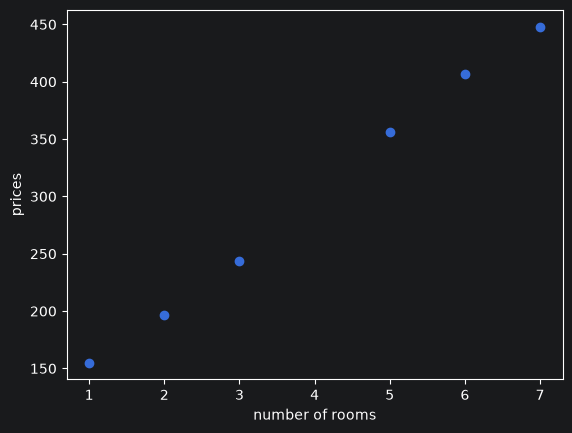

In [8]:
plot_points(features, labels)

## Coding the tricks
- Simple Trick
- Absolute Trick
- Square Trick

In [5]:
def simple_trick(base_price, price_per_room, num_rooms, price):
    """How to get the line to move in the linear regression algorithm"""
    eta_1 = random.random() * 0.1
    eta_2 = random.random() * 0.1
    predicted_price = base_price + price_per_room * num_rooms

    # the 4 cases of the simple trick.
    if price > predicted_price and num_rooms > 0:
        price_per_room += eta_1
        base_price += eta_2
    if price > predicted_price and num_rooms < 0:
        price_per_room -= eta_1
        base_price += eta_2
    if price < predicted_price and num_rooms > 0:
        price_per_room -= eta_1
        base_price -= eta_2
    if price < predicted_price and num_rooms < 0:
        price_per_room += eta_1
        base_price -= eta_2
    return price_per_room, base_price

In [6]:
def square_trick(base_price, price_per_room, num_rooms, price, learning_rate):
    """Optimization of the simple trick to move the line closer to a point."""
    predicted_price = base_price + price_per_room * num_rooms
    base_price += learning_rate * (price - predicted_price)
    price_per_room += learning_rate * num_rooms * (price - predicted_price)
    return price_per_room, base_price

In [7]:
def absolute_trick(base_price, price_per_room, num_rooms, price, learning_rate):
    """Simplifying the square trick to move the line closer to a point."""
    predicted_price = base_price + price_per_room * num_rooms

    if price > predicted_price:
        price_per_room += learning_rate * num_rooms
        base_price += learning_rate
    else:
        price_per_room -= learning_rate * num_rooms
        base_price -= learning_rate
    return price_per_room, base_price

## Running the Linear Regression Algorithm
The linear regression algorithm consists of:

- Starting with random weights.
- Iterating the simple/square/absolute trick many times.

The square trick is more popular as it scales well.

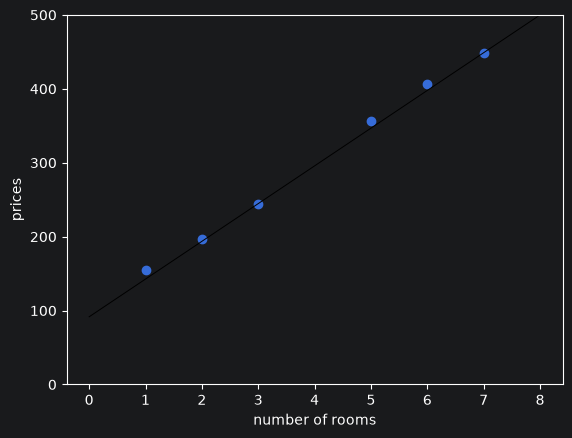

Price per room: 51.04430678220095
Base price: 91.59448307644864


(np.float64(51.04430678220095), np.float64(91.59448307644864))

In [27]:
# We set a random seed in order to always get the same results.
random.seed(0)

def linear_regression(features, labels, learning_rate=0.01, epochs=1000):
    """Linear regression algorithm to produce model weights."""
    # start with random values for the weights and bias.
    price_per_room = random.random()
    base_price = random.random()

    for epoch in range(epochs):
        # draw the line for visualization
        # draw_line(price_per_room, base_price, starting=0, ending=8)

        i = random.randint(0, len(features)-1)
        num_rooms = features[i]
        price = labels[i]

        # determine the new weights and base.
        price_per_room, base_price = square_trick(base_price, price_per_room,
                                                  num_rooms, price, learning_rate)

    # plot the graph.
    draw_line(price_per_room, base_price, 'black', starting=0, ending=8)
    plot_points(features, labels)
    print('Price per room:', price_per_room)
    print('Base price:', base_price)

    return price_per_room, base_price


linear_regression(features, labels, learning_rate=0.01, epochs=1000)

Now we can use the weights and bias to predict the price of a house with 4 rooms.